### <u><B> *K MEANS CLUSTERING*</B></U>

It's a distance based unsupervised clustering algorithm where data points that are close to each other are grouped in a given number of  centroids/groups

OR

 K-means is an unsupervised, centroid-based algorithm that partitions 
n
 points into K clusters by assigning each point to the nearest centroid and iteratively updating centroids to minimize within-cluster squared distances (“inertia”).

Goal:
Group similar data points together without labels

<u>CLUSTER:</u>
A group of data points that are closer to each other than to others

choose the number of clusters: 
$$
K \in \mathbb{N}
$$

<u>CENTROID :</u>
The mean position of all points in a cluster

$$
\text{Centroid} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

<u>DISTANCE METRIC</u>
K Means works on distance, usually: 

- Euclidean Distance
$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$


*STEPS IN K-MEANS ALGORITHM:*
1. Choose K:
You decide how many ckusters you want

2. Initialize Centroids :
Randomly place K points

3. Assignment Step :
Each data point -> Nearest centroid

4. Update Step :
Recalculate centroid as the mean of assigned points

5. Repeat :
until

- Centroid don't move OR
- max iterations reached

<img src="kmeans.png" width=400>

Methods to select the optional number of cluster in k-means clustering

-> ELBOW METHOD

-> SILHOUETTE METHOD

In [41]:
import numpy as np
import pandas as pd

np.random.seed(42)

# -------- Cluster 1: Low CGPA, Low IQ --------
cgpa_1 = np.random.normal(loc=5.5, scale=0.5, size=50)
iq_1   = np.random.normal(loc=90, scale=5, size=50)

# -------- Cluster 2: Medium CGPA, Medium IQ --------
cgpa_2 = np.random.normal(loc=7.0, scale=0.4, size=50)
iq_2   = np.random.normal(loc=110, scale=6, size=50)

# -------- Cluster 3: High CGPA, High IQ --------
cgpa_3 = np.random.normal(loc=8.8, scale=0.3, size=50)
iq_3   = np.random.normal(loc=130, scale=5, size=50)

# Combine all clusters
cgpa = np.concatenate([cgpa_1, cgpa_2, cgpa_3])
iq   = np.concatenate([iq_1, iq_2, iq_3])

# Create DataFrame
df = pd.DataFrame({
    'CGPA': np.round(cgpa, 2),
    'IQ': np.round(iq, 1)
})

df.head()


,CGPA,IQ
0,5.75,91.6
1,5.43,88.1
2,5.82,86.6
3,6.26,93.1
4,5.38,95.2


In [42]:
df.describe()


,CGPA,IQ
count,150.000000,150.000000
mean,7.072267,110.164667
std,1.473663,17.062857
min,4.520000,76.900000
25%,5.675000,93.350000
50%,7.005000,111.150000
75%,8.600000,126.500000
max,9.960000,140.700000


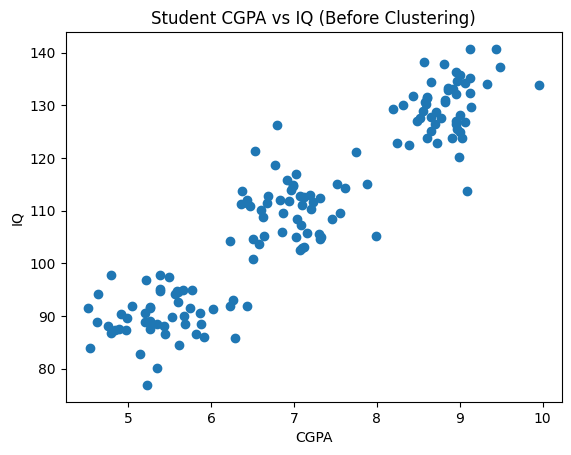

In [43]:
import matplotlib.pyplot as plt

plt.scatter(df['CGPA'], df['IQ'])
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Student CGPA vs IQ (Before Clustering)")
plt.show()


In [44]:
from sklearn.cluster import KMeans

In [45]:
km=KMeans(n_clusters=3)
km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [46]:
y_pred=km.fit_predict(df[['CGPA','IQ']])
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [47]:
df['CLUSTER']=y_pred
df.head()

,CGPA,IQ,CLUSTER
0,5.75,91.6,0
1,5.43,88.1,0
2,5.82,86.6,0
3,6.26,93.1,0
4,5.38,95.2,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_12272\1549115432.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


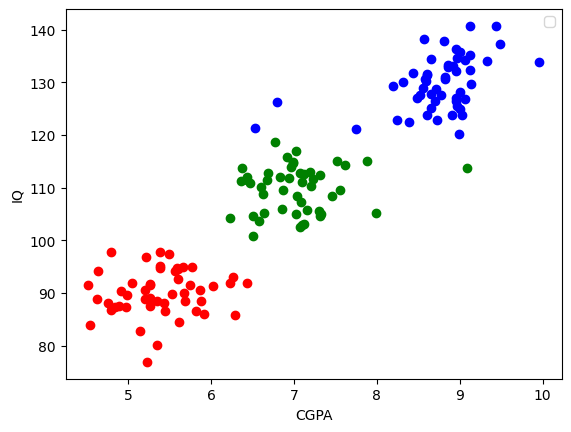

In [48]:
df0=df[df.CLUSTER==0]
df1=df[df.CLUSTER==1]
df2=df[df.CLUSTER==2]
plt.scatter(df0.CGPA,df0['IQ'],color='red')
plt.scatter(df1.CGPA,df1['IQ'],color='blue')
plt.scatter(df2.CGPA,df2['IQ'],color='green')

plt.xlabel("CGPA")
plt.ylabel('IQ')
plt.legend()
plt.show()

In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(df[['CGPA']])
(df[['CGPA']])=scaler.transform((df[['CGPA']]))

scaler.fit(df[['IQ']])
(df[['IQ']])=scaler.transform((df[['IQ']]))
df



,CGPA,IQ,CLUSTER
0,0.226103,0.230408,0
1,0.167279,0.175549,0
2,0.238971,0.152038,0
3,0.319853,0.253918,0
4,0.158088,0.286834,0
...,...,...,...
145,0.768382,0.777429,1
146,0.761029,0.902821,1
147,0.750000,0.855799,1
148,0.884191,0.896552,1


In [50]:
km = KMeans(n_clusters=3)
y_pred=km.fit_predict(df[['CGPA','IQ']])
y_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [51]:
df['CLUSTER']=y_pred
df

,CGPA,IQ,CLUSTER
0,0.226103,0.230408,2
1,0.167279,0.175549,2
2,0.238971,0.152038,2
3,0.319853,0.253918,2
4,0.158088,0.286834,2
...,...,...,...
145,0.768382,0.777429,0
146,0.761029,0.902821,0
147,0.750000,0.855799,0
148,0.884191,0.896552,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_12272\3930136345.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


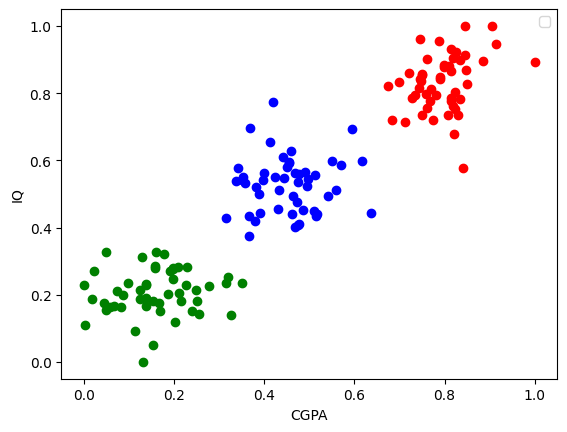

In [52]:
df0=df[df.CLUSTER==0]
df1=df[df.CLUSTER==1]
df2=df[df.CLUSTER==2]
plt.scatter(df0.CGPA,df0['IQ'],color='red')
plt.scatter(df1.CGPA,df1['IQ'],color='blue')
plt.scatter(df2.CGPA,df2['IQ'],color='green')

plt.xlabel("CGPA")
plt.ylabel('IQ')
plt.legend()
plt.show()


In [53]:
km.cluster_centers_

array([[0.79511029, 0.83062696],
       [0.45297794, 0.52670846],
       [0.15941176, 0.20683386]])

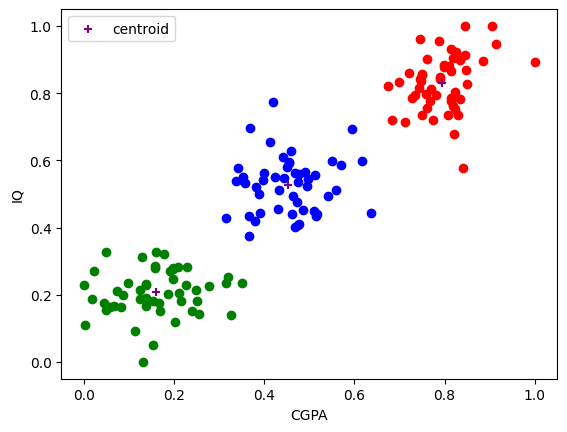

In [54]:
plt.scatter(df0.CGPA,df0['IQ'],color='red')
plt.scatter(df1.CGPA,df1['IQ'],color='blue')
plt.scatter(df2.CGPA,df2['IQ'],color='green')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='+',label='centroid')
plt.xlabel("CGPA")
plt.ylabel('IQ')
plt.legend()
plt.show()

#### ELBOW METHOD:

In [55]:
k_rng = range(1,10)
sse=[]
for k in k_rng:
    km= KMeans(n_clusters=k)
    km.fit(df[['CGPA','IQ']])
    sse.append(km.inertia_) # inertia will give the sum of squared error

In [56]:
sse

[21.591472257130363,
 6.319539847642231,
 1.73893359336308,
 1.4712933834493804,
 1.3822050220196966,
 1.1391879577402135,
 0.9297216399349764,
 0.8157055441309949,
 0.7819539692768442]

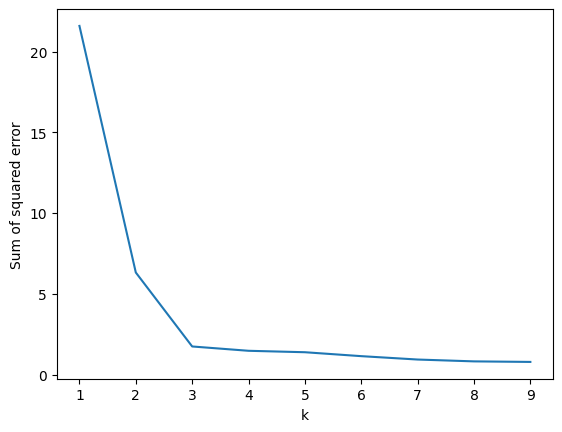

In [57]:
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

so,best K to select is 3 , from the elbow graph we understood


#### SILHOUETTE SCORE

The silhouette score is a measure of how well each data point fits into its assigned cluster compared with other clusters.



K = 2, Silhouette = 0.556
K = 3, Silhouette = 0.677
K = 4, Silhouette = 0.560
K = 5, Silhouette = 0.449
K = 6, Silhouette = 0.365
K = 7, Silhouette = 0.380
K = 8, Silhouette = 0.374
K = 9, Silhouette = 0.368
K = 10, Silhouette = 0.348


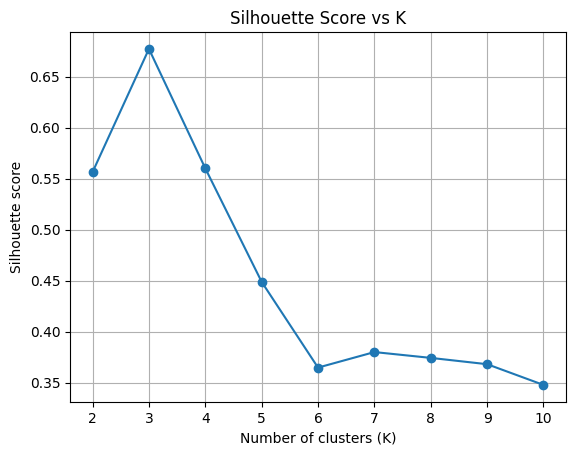

In [58]:
from sklearn.metrics import silhouette_score

K_range = range(2, 11)   # silhouette needs at least 2 clusters
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(df[['CGPA','IQ']])
    sil = silhouette_score(df[['CGPA','IQ']], labels, metric="euclidean")
    sil_scores.append(sil)
    print(f"K = {k}, Silhouette = {sil:.3f}")
plt.plot(K_range, sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

The best 
K
is usually the one with the highest silhouette score.

#### Why K means was not enough:
1. You must specify K in advance
-> elbow method is subjective
-> Silhoutte score can mislead
-> Different K , Different business coclusions

2. Assumes clusters are Spherical

3. Sensitivity to Feature scaling
-> k-means uses euclidean distance
-> if features are not scaled :
- one feuture dominates
- clustering becomes meaningless

4. Extremely sensitive to outliers

5. only works with Numeric data

“K-Means is efficient and intuitive, but its assumptions about cluster shape, density, and the need to predefine K make it unsuitable for many real-world datasets. These limitations motivated density-based and hierarchical clustering approaches.”